# LangGraph live optimization comparison across Trace / OTEL / sys.monitoring

This notebook runs the live comparison module and renders a shared analysis report.

- It uses the OpenRouter API when `OPENROUTER_API_KEY` is set.
- It defaults to `OPENROUTER_MODEL=google/gemini-3-flash-preview` when the model env var is absent.
- In CI or local runs without credentials, it prints a skip message and exits successfully.


## Optimization comparison

| config | runtime_s | baseline | best | gain | best_iteration | stability_std | score_history |
|---|---:|---:|---:|---:|---:|---:|---|
| trace | 71.749 | 0.752 | 0.928 | 0.176 | 4 | 0.003 | [0.752, 0.805, 0.92, 0.898, 0.928, 0.923] |
| trace+otel | 76.288 | 0.822 | 0.950 | 0.128 | 2 | 0.025 | [0.822, 0.715, 0.95, 0.937, 0.907, 0.885] |
| otel | 80.465 | 0.669 | 0.950 | 0.281 | 4 | 0.014 | [0.669, 0.842, 0.92, 0.907, 0.95, 0.922] |
| trace+sysmon | 78.316 | 0.732 | 0.923 | 0.192 | 4 | 0.022 | [0.732, 0.714, 0.92, 0.92, 0.923, 0.88] |
| trace+otel+sysmon | 77.963 | 0.714 | 0.923 | 0.210 | 3 | 0.018 | [0.714, 0.712, 0.92, 0.923, 0.88, 0.898] |
| otel+sysmon | 93.479 | 0.842 | 0.950 | 0.108 | 2 | 0.023 | [0.842, 0.715, 0.95, 0.923, 0.923, 0.887] |
| sysmon | 77.312 | 0.822 | 0.944 | 0.122 | 2 | 0.026 | [0.822, 0.669, 0.944, 0.923, 0.88, 0.887] |

## trace
- Runtime: `71.749s`
- Baseline score: `0.752`
- Best score: `0.928`
- Score gain: `0.176`
- Best iteration: `4`
- Post-update stability std: `0.003`
- Score history: `[0.752, 0.805, 0.92, 0.898, 0.928, 0.923]`
- Best updates: `[]`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR (Clustered Regularly Interspaced Short Palindromic Repeats) is a revolutionary gene-editing technology that allows for precise modifications to DNA in various organisms.

### Mechanism of CRISPR
**Components**: CRISPR technology primarily involves the Cas9 enzyme, which acts as molecular scissors, and a guide RNA (gRNA) that directs Cas9 to the specific DNA sequence to be edited.  
**Process**: The CRISPR system works by first introducing the gRNA into a cell, where it binds to the tar...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['make_trace_case.planner_node', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

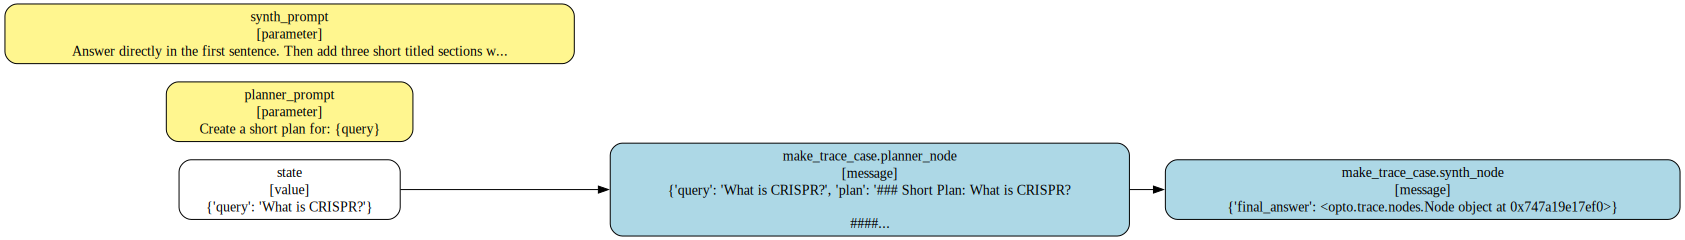

## trace+otel
- Runtime: `76.288s`
- Baseline score: `0.822`
- Best score: `0.950`
- Score gain: `0.128`
- Best iteration: `2`
- Post-update stability std: `0.025`
- Score history: `[0.822, 0.715, 0.95, 0.937, 0.907, 0.885]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR, or Clustered Regularly Interspaced Short Palindromic Repeats, is a revolutionary gene-editing technology that allows for precise modifications to DNA in various organisms.

### Mechanism of CRISPR
CRISPR functions through a combination of specific components: CRISPR sequences in bacterial genomes store segments of viral DNA, while the Cas9 protein acts as a molecular scissors that cuts DNA. The process begins with guide RNA, which is designed to match a specific DNA sequence, directin...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['make_trace_case.planner_node', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

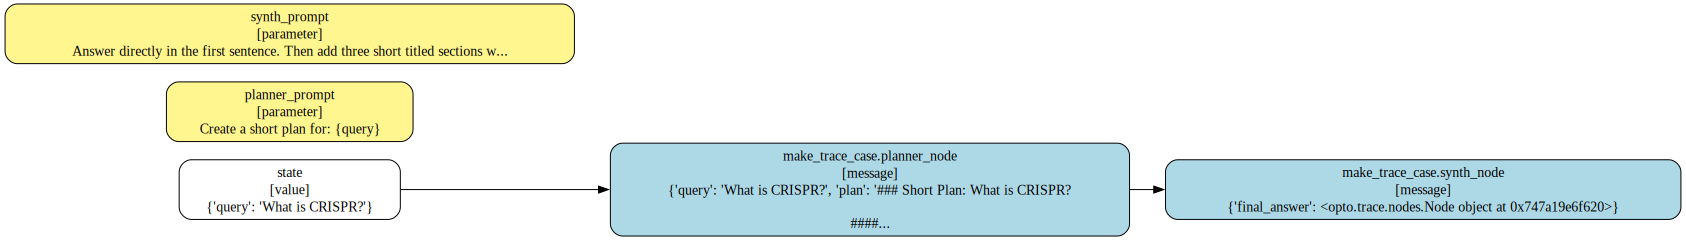

### observer otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['make_trace_case.planner_node', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `2`
- Span names: `['make_trace_case.planner_node', 'make_trace_case.synth_node']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

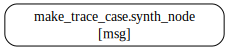

## otel
- Runtime: `80.465s`
- Baseline score: `0.669`
- Best score: `0.950`
- Score gain: `0.281`
- Best iteration: `4`
- Post-update stability std: `0.014`
- Score history: `[0.669, 0.842, 0.92, 0.907, 0.95, 0.922]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR (Clustered Regularly Interspaced Short Palindromic Repeats) is a revolutionary gene-editing technology that allows for precise modifications to DNA in various organisms.

### Mechanism of CRISPR
**Components**: CRISPR technology primarily involves the Cas9 enzyme, which acts as molecular scissors, and a guide RNA (gRNA) that directs Cas9 to the specific DNA sequence to be edited.  
**Process**: The CRISPR system works by first using the gRNA to locate the target DNA sequence. Once boun...
```

### backend otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['llm.chat.completion', 'llm.chat.completion', 'planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `5`
- Span names: `['llm.chat.completion', 'planner_node', 'llm.chat.completion', 'synth_node', 'langgraph-agent.invoke']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

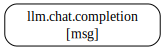

## trace+sysmon
- Runtime: `78.316s`
- Baseline score: `0.732`
- Best score: `0.923`
- Score gain: `0.192`
- Best iteration: `4`
- Post-update stability std: `0.022`
- Score history: `[0.732, 0.714, 0.92, 0.92, 0.923, 0.88]`
- Best updates: `[]`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR is a revolutionary gene-editing technology that allows for precise modifications to DNA in living organisms.

### Mechanism of CRISPR
CRISPR consists of two main components: CRISPR sequences, which serve as a genetic memory of past viral infections, and the Cas9 enzyme, which acts as molecular scissors to cut DNA. The process begins with the guide RNA, which is designed to match a specific DNA sequence, directing the Cas9 enzyme to the target site for cleavage, leading to DNA repair me...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['make_trace_case.planner_node', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

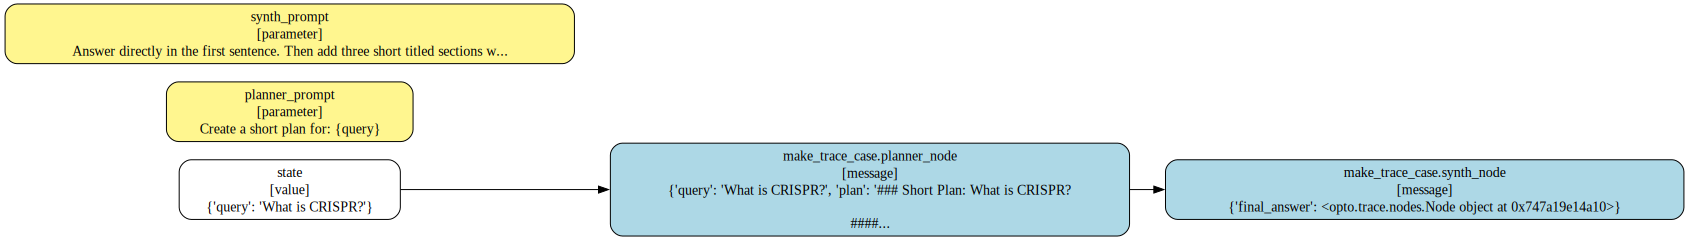

### observer sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

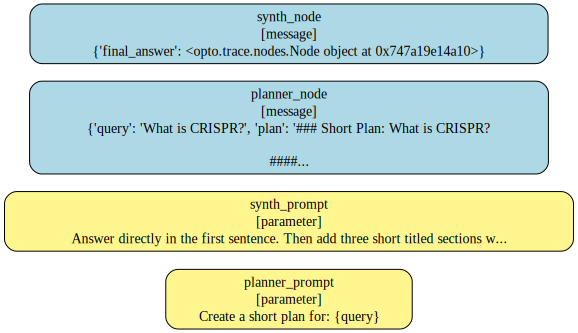

## trace+otel+sysmon
- Runtime: `77.963s`
- Baseline score: `0.714`
- Best score: `0.923`
- Score gain: `0.210`
- Best iteration: `3`
- Post-update stability std: `0.018`
- Score history: `[0.714, 0.712, 0.92, 0.923, 0.88, 0.898]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR (Clustered Regularly Interspaced Short Palindromic Repeats) is a revolutionary gene-editing technology that allows for precise modifications to DNA in various organisms.

### Mechanism of CRISPR
**Components**: CRISPR technology primarily involves the Cas9 enzyme, which acts as molecular scissors, and a guide RNA (gRNA) that directs Cas9 to the specific DNA sequence to be edited.  
**Process**: The CRISPR system works by first introducing the gRNA into a cell, where it binds to the tar...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['make_trace_case.planner_node', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

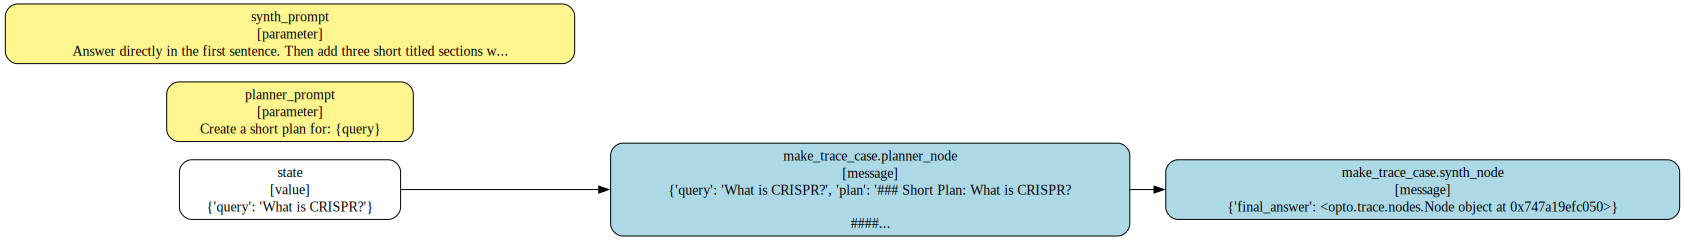

### observer sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

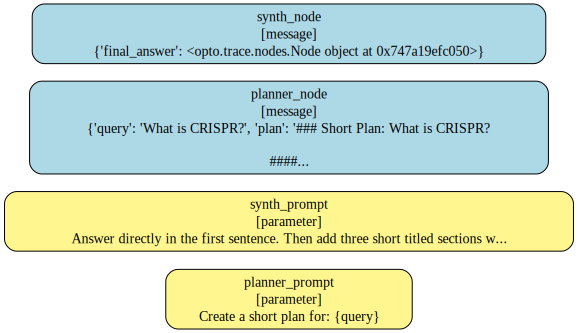

### observer otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['make_trace_case.planner_node', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `2`
- Span names: `['make_trace_case.planner_node', 'make_trace_case.synth_node']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

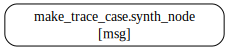

## otel+sysmon
- Runtime: `93.479s`
- Baseline score: `0.842`
- Best score: `0.950`
- Score gain: `0.108`
- Best iteration: `2`
- Post-update stability std: `0.023`
- Score history: `[0.842, 0.715, 0.95, 0.923, 0.923, 0.887]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR (Clustered Regularly Interspaced Short Palindromic Repeats) is a revolutionary gene-editing technology that allows for precise modifications to DNA in various organisms.

### Mechanism of CRISPR
**Components**: CRISPR technology primarily involves the Cas9 enzyme, which acts as molecular scissors, and a guide RNA (gRNA) that directs Cas9 to the specific DNA sequence to be edited.  
**Process**: The CRISPR system works by first introducing the gRNA into a cell, where it binds to the tar...
```

### backend otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['llm.chat.completion', 'llm.chat.completion', 'planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `5`
- Span names: `['llm.chat.completion', 'planner_node', 'llm.chat.completion', 'synth_node', 'langgraph-agent.invoke']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

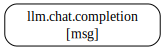

### observer sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

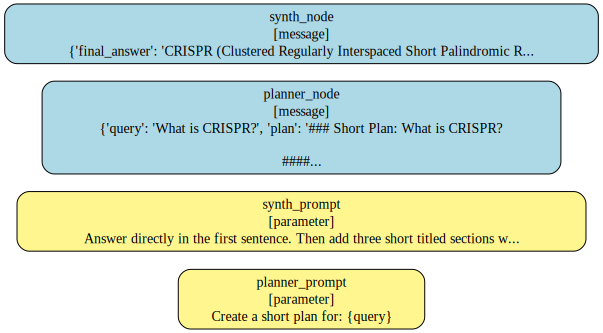

## sysmon
- Runtime: `77.312s`
- Baseline score: `0.822`
- Best score: `0.944`
- Score gain: `0.122`
- Best iteration: `2`
- Post-update stability std: `0.026`
- Score history: `[0.822, 0.669, 0.944, 0.923, 0.88, 0.887]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR (Clustered Regularly Interspaced Short Palindromic Repeats) is a revolutionary gene-editing technology that allows for precise modifications to DNA in various organisms.

### Mechanism of CRISPR
**Components**: CRISPR technology primarily consists of the Cas9 enzyme, which acts as molecular scissors, and a guide RNA (gRNA) that directs Cas9 to the specific DNA sequence to be edited.  
**Process**: The CRISPR process involves the gRNA binding to the target DNA sequence, the Cas9 enzyme ...
```

### backend sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}"
}
```

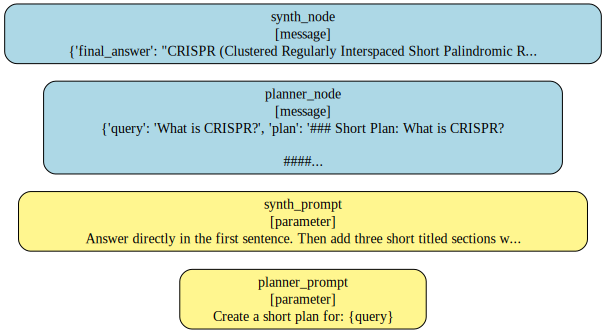

[{'config': 'trace',
  'runtime_s': 71.749,
  'baseline_score': 0.752,
  'best_score': 0.928,
  'score_gain': 0.176,
  'best_iteration': 4,
  'score_history': [0.752, 0.805, 0.92, 0.898, 0.928, 0.923],
  'stability_std': 0.003,
  'best_updates': {},
  'final_synth_prompt': 'Answer directly in the first sentence. Then add three short titled sections with concrete mechanisms, examples, and caveats when useful. Keep it factual and concise: {query}\nPlan: {plan}',
  'final_answer': "CRISPR (Clustered Regularly Interspaced Short Palindromic Repeats) is a revolutionary gene-editing technology that allows for precise modifications to DNA in various organisms.\n\n### Mechanism of CRISPR\n**Components**: CRISPR technology primarily involves the Cas9 enzyme, which acts as molecular scissors, and a guide RNA (gRNA) that directs Cas9 to the specific DNA sequence to be edited.  \n**Process**: The CRISPR system works by first introducing the gRNA into a cell, where it binds to the target DNA sequenc

In [1]:
import importlib.util
from pathlib import Path

candidates = [
    Path('examples/notebooks/demo_langgraph_instrument_and_compare_observers.py'),
    Path('demo_langgraph_instrument_and_compare_observers.py'),
]

for candidate in candidates:
    if candidate.exists():
        spec = importlib.util.spec_from_file_location('compare_observers_demo', candidate)
        module = importlib.util.module_from_spec(spec)
        assert spec.loader is not None
        spec.loader.exec_module(module)
        rows = module.run_notebook_demo()
        break
else:
    raise FileNotFoundError('Could not locate demo_langgraph_instrument_and_compare_observers.py')

rows
